# Cross-Sectional Stock Return Prediction

This notebook runs the attention experiment from `run_project_mhattn.py`.
Each model uses its own hyperparameters so the notebook matches the script-based runs more closely.


In [10]:
import importlib
import sys
from pathlib import Path

import pandas as pd

project_root = Path.cwd().resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import stock_return_project4 as srp
import run_project_mhattn as mh

srp = importlib.reload(srp)
mh = importlib.reload(mh)
print(srp.__file__)
print(mh.__file__)


/Users/hlc/Desktop/UCLA Courses/ECE C147A/Project/stock_return_project4.py
/Users/hlc/Desktop/UCLA Courses/ECE C147A/Project/run_project_mhattn.py


In [2]:
# Quick run defaults for the attention experiment.
START_DATE = "2015-01-01"
END_DATE = "2025-01-01"
LOOKBACK = 60
HORIZON = 5
UNIVERSE = "small"  # small | sp500 | nasdaq100 | auto
MODELS = ["RNN", "LSTM", "GRU", "TRANSFORMER"]
ATTN_HEADS = 4
DEVICE = mh.resolve_device()

NASDAQ100_TICKERS = [
    "ADBE", "AMD", "ABNB", "ALNY", "GOOGL", "GOOG", "AMZN", "AEP", "AMGN", "ADI",
    "AAPL", "AMAT", "APP", "ARM", "ASML", "TEAM", "ADSK", "ADP", "AXON", "BKR",
    "BIIB", "BKNG", "AVGO", "CDNS", "CDW", "CHTR", "CTAS", "CSCO", "CCEP", "CTSH",
    "CPRT", "CSGP", "COST", "CRWD", "DDOG", "DXCM", "DASH", "EA", "EXC", "FAST",
    "FTNT", "GEHC", "GILD", "HON", "IDXX", "INTC", "INTU", "ISRG", "KDP", "KHC",
    "KLAC", "LIN", "LULU", "MAR", "MRVL", "MELI", "META", "MCHP", "MU", "MSFT",
    "MSTR", "MDLZ", "MDB", "MNST", "NFLX", "NVDA", "NXPI", "ORLY", "ODFL", "ON",
    "PCAR", "PLTR", "PANW", "PAYX", "PYPL", "PDD", "PEP", "QCOM", "REGN", "ROP",
    "ROST", "CRWD", "SBUX", "SNPS", "TTWO", "TMUS", "TSLA", "TXN", "TRI", "VRSK",
    "VRTX", "WMT", "WBD", "WDC", "WDAY", "XEL", "ZS",
]

UNIVERSE_TO_TICKERS = {
    "small": srp.DEFAULT_LIQUID_TICKERS,
    "sp500": None,
    "nasdaq100": NASDAQ100_TICKERS,
    "auto": None,
}
TICKERS = UNIVERSE_TO_TICKERS[UNIVERSE]
print(f"Universe: {UNIVERSE}")

# Universe filter: keep stocks that cover nearly the full sample window.
START_BUFFER_DAYS = 5
END_BUFFER_DAYS = 5
MIN_COVERAGE_RATIO = 0.95


Universe: small


In [3]:
raw_prices = srp.download_price_history(start=START_DATE, end=END_DATE, tickers=TICKERS)

flat_prices = srp.flatten_price_frame(raw_prices).dropna(subset=["Close"]).copy()
all_dates = pd.Index(sorted(pd.to_datetime(flat_prices["Date"].unique())))
date_to_pos = {date: idx for idx, date in enumerate(all_dates)}

coverage = (
    flat_prices.groupby("Ticker")
    .agg(
        first_date=("Date", "min"),
        last_date=("Date", "max"),
        n_dates=("Date", "nunique"),
    )
    .reset_index()
)
coverage["first_pos"] = pd.to_datetime(coverage["first_date"]).map(date_to_pos)
coverage["last_pos"] = pd.to_datetime(coverage["last_date"]).map(date_to_pos)
coverage["coverage_ratio"] = coverage["n_dates"] / len(all_dates)

eligible_tickers = coverage.loc[
    (coverage["first_pos"] <= START_BUFFER_DAYS)
    & (coverage["last_pos"] >= len(all_dates) - 1 - END_BUFFER_DAYS)
    & (coverage["coverage_ratio"] >= MIN_COVERAGE_RATIO),
    "Ticker",
].tolist()

filtered_prices = raw_prices.loc[
    :,
    raw_prices.columns.get_level_values(0).isin(eligible_tickers),
]

print(
    f"Kept {len(eligible_tickers)} / {coverage.shape[0]} tickers "
    f"with >= {MIN_COVERAGE_RATIO:.0%} coverage and near-full sample history."
)
print(
    "Dropped examples:",
    coverage.loc[~coverage["Ticker"].isin(eligible_tickers), "Ticker"].head(10).tolist(),
)

experiment_data = srp.prepare_experiment_data(
    filtered_prices,
    horizon=HORIZON,
    lookback=LOOKBACK,
    train_size=0.7,
    val_size=0.15,
)
for split_name, split_df in experiment_data.splits.items():
    print(split_name, split_df["Date"].min(), split_df["Date"].max(), len(split_df))


Kept 49 / 50 tickers with >= 95% coverage and near-full sample history.
Dropped examples: ['UBER']
train 2015-02-02 00:00:00 2021-12-31 00:00:00 85407
val 2022-01-03 00:00:00 2023-06-29 00:00:00 18326
test 2023-06-30 00:00:00 2024-12-23 00:00:00 18326


In [4]:
MODEL_CONFIGS = {
    "RNN": srp.TrainConfig(
        batch_size=128,
        hidden_dim=64,
        num_layers=1,
        dropout=0.0,
        learning_rate=1e-4,
        weight_decay=1e-5,
        max_epochs=20,
        patience=6,
        grad_clip=1.0,
        device=DEVICE,
    ),
    "LSTM": srp.TrainConfig(
        batch_size=128,
        hidden_dim=64,
        num_layers=2,
        dropout=0.15,
        learning_rate=3e-4,
        weight_decay=1e-5,
        max_epochs=25,
        patience=6,
        grad_clip=1.0,
        device=DEVICE,
    ),
    "GRU": srp.TrainConfig(
        batch_size=128,
        hidden_dim=64,
        num_layers=2,
        dropout=0.15,
        learning_rate=1e-4,
        weight_decay=1e-5,
        max_epochs=25,
        patience=6,
        grad_clip=1.0,
        device=DEVICE,
    ),
    "TRANSFORMER": srp.TrainConfig(
        batch_size=256,
        hidden_dim=160,
        num_layers=3,
        dropout=0.15,
        num_heads=8,
        learning_rate=3e-4,
        weight_decay=5e-5,
        max_epochs=35,
        patience=10,
        grad_clip=1.0,
        device=DEVICE,
    ),
}

input_dim = len(experiment_data.feature_columns)
results = {}

for model_name in MODELS:
    train_config = MODEL_CONFIGS[model_name]
    print(f"=== Notebook model: {model_name} ===")

    if model_name == "RNN":
        model = srp.build_model(
            model_name="RNN",
            input_dim=input_dim,
            hidden_dim=train_config.hidden_dim,
            num_layers=train_config.num_layers,
            dropout=train_config.dropout,
        )
    elif model_name in {"LSTM", "GRU"}:
        model = mh.AttentionSequenceRegressor(
            input_dim=input_dim,
            hidden_dim=train_config.hidden_dim,
            num_layers=train_config.num_layers,
            dropout=train_config.dropout,
            cell_type=model_name,
            num_attn_heads=ATTN_HEADS,
        )
    elif model_name == "TRANSFORMER":
        model = srp.build_model(
            model_name="TRANSFORMER",
            input_dim=input_dim,
            hidden_dim=train_config.hidden_dim,
            num_layers=train_config.num_layers,
            dropout=train_config.dropout,
            num_heads=train_config.num_heads,
        )
    else:
        raise ValueError(f"Unsupported model: {model_name}")

    results[model_name] = mh.run_experiment(
        model,
        model_name,
        experiment_data,
        train_config,
    )


=== Notebook model: RNN ===

=== Training RNN ===
[train] batch 1/645 - loss: 0.051914
[train] batch 200/645 - loss: 0.005690
[train] batch 400/645 - loss: 0.003913
[train] batch 600/645 - loss: 0.003229
[train] batch 645/645 - loss: 0.003126
[val] batch 1/121 - loss: 0.002845
[val] batch 121/121 - loss: 0.002483
Epoch 1/20 - train_loss: 0.003126, val_loss: 0.002483, time: 10.2s
Validation improved; checkpoint updated.
[train] batch 1/645 - loss: 0.001704
[train] batch 200/645 - loss: 0.001742
[train] batch 400/645 - loss: 0.001701
[train] batch 600/645 - loss: 0.001664
[train] batch 645/645 - loss: 0.001662
[val] batch 1/121 - loss: 0.002169
[val] batch 121/121 - loss: 0.002265
Epoch 2/20 - train_loss: 0.001662, val_loss: 0.002265, time: 9.9s
Validation improved; checkpoint updated.
[train] batch 1/645 - loss: 0.001329
[train] batch 200/645 - loss: 0.001568
[train] batch 400/645 - loss: 0.001562
[train] batch 600/645 - loss: 0.001556
[train] batch 645/645 - loss: 0.001566
[val] batch 

In [5]:
summary = srp.build_summary_frame(results)
summary


,model,mean_ic,std_ic,ic_t_stat,mean_rank_ic,std_rank_ic,rank_ic_t_stat,mean_return,volatility,sharpe_ratio
0,TRANSFORMER,0.080473,0.324093,4.399905,0.049148,0.279299,3.118179,0.007260,0.027104,4.251901
1,LSTM,0.064552,0.273494,4.182387,0.049350,0.233932,3.738234,0.006119,0.022240,4.367279
2,GRU,0.058607,0.279512,3.715490,0.024950,0.225635,1.959419,0.004622,0.023591,3.110319
3,RNN,0.016607,0.211676,1.390253,-0.002092,0.189846,-0.195219,0.000550,0.019557,0.446051


# Result Visualizations

Plots for loss curves, IC/RankIC, portfolio performance, and model comparison.


Visualizing model: TRANSFORMER


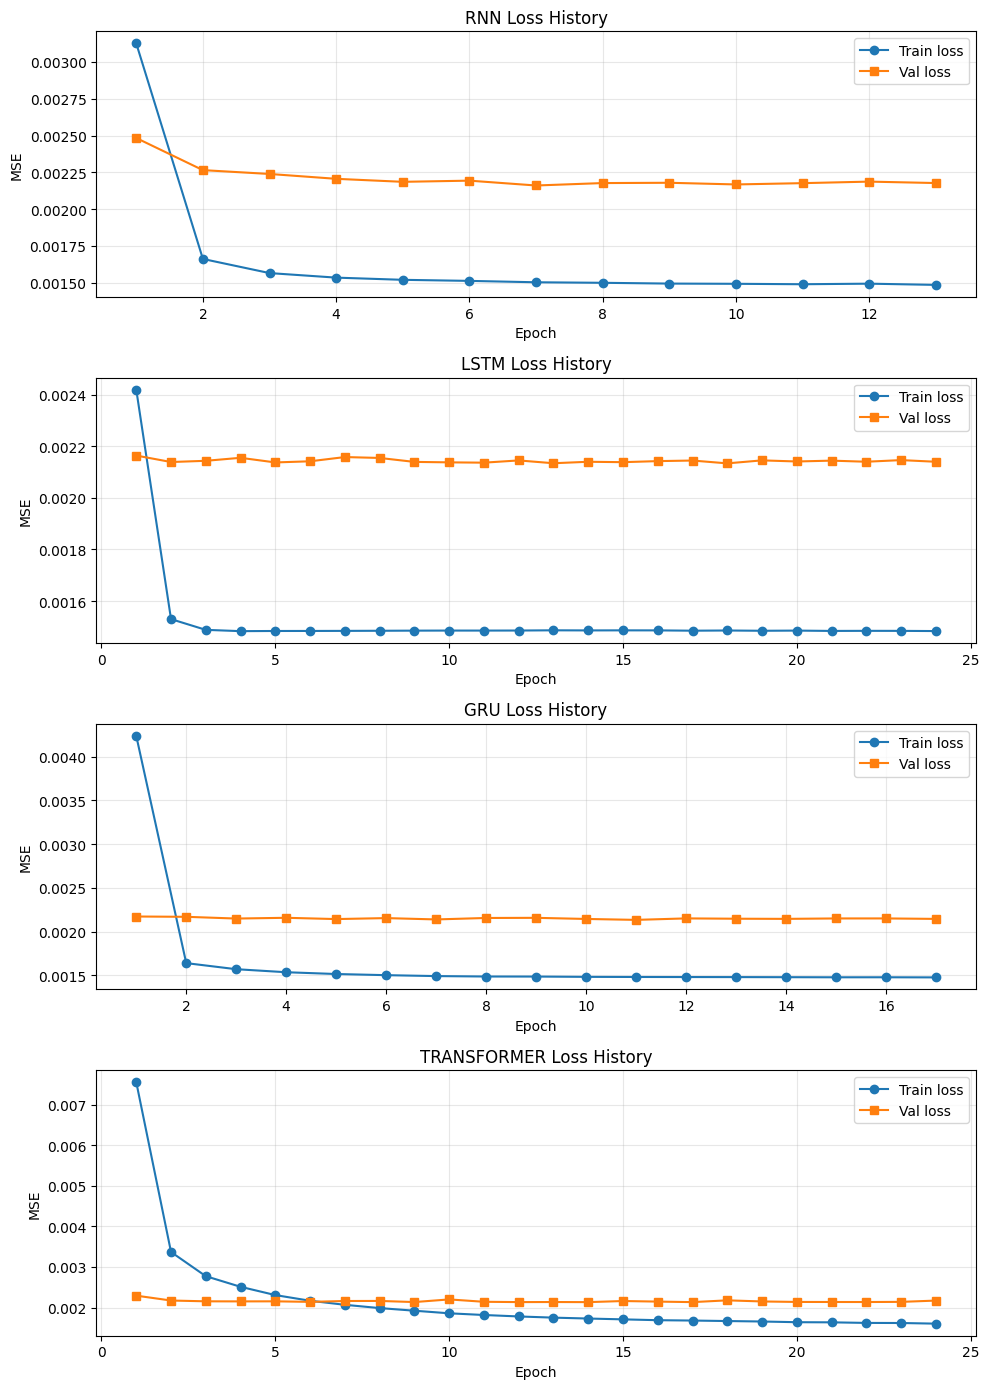

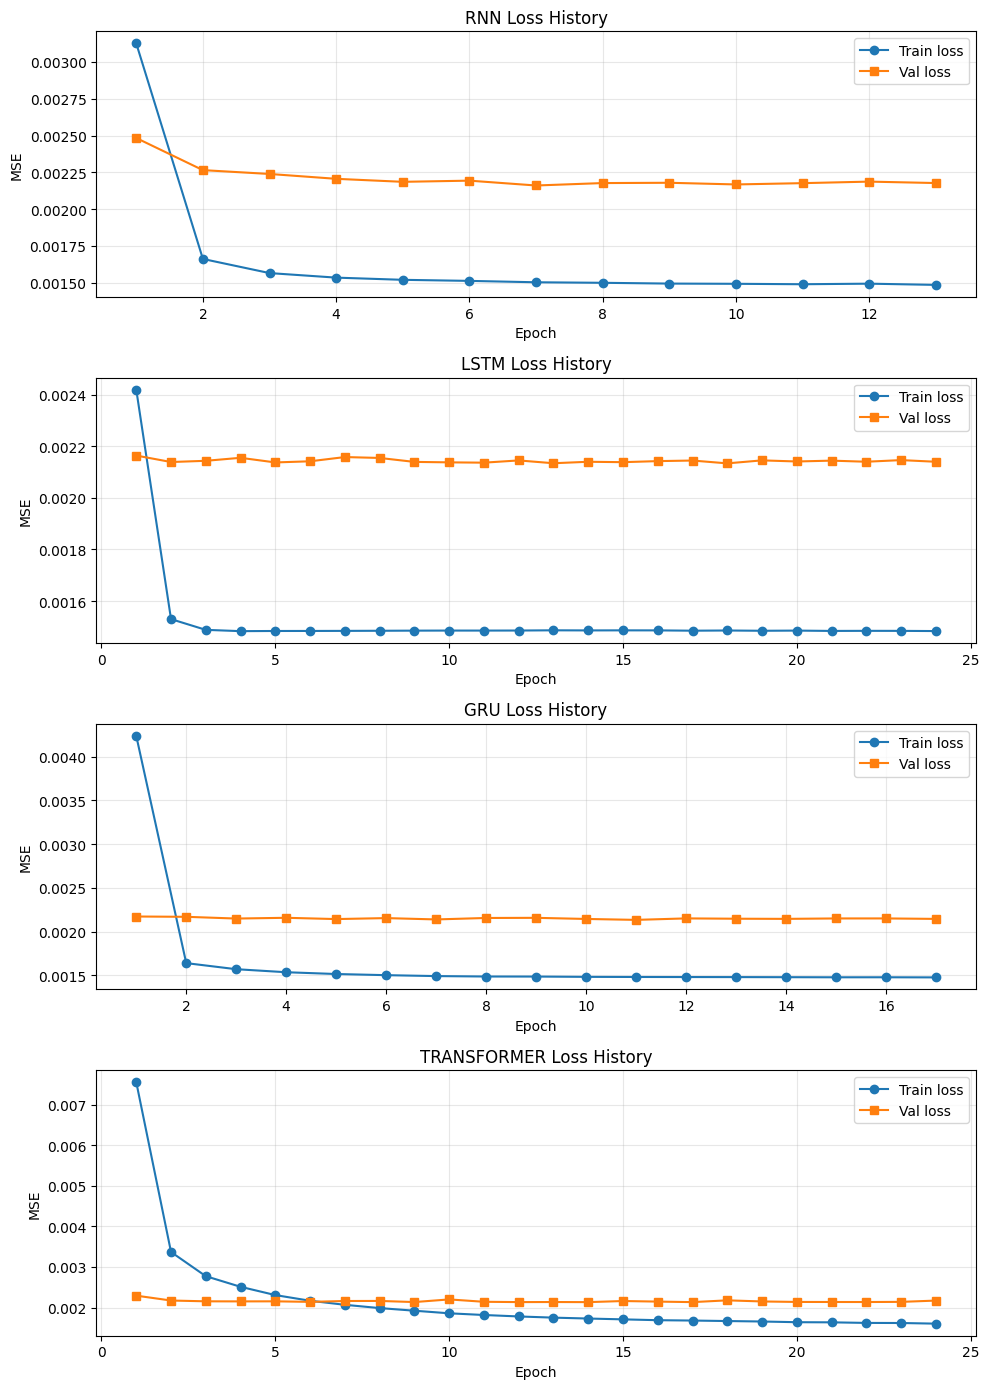

In [6]:
best_model = summary.iloc[0]["model"]
print("Visualizing model:", best_model)
srp.plot_training_histories(results)


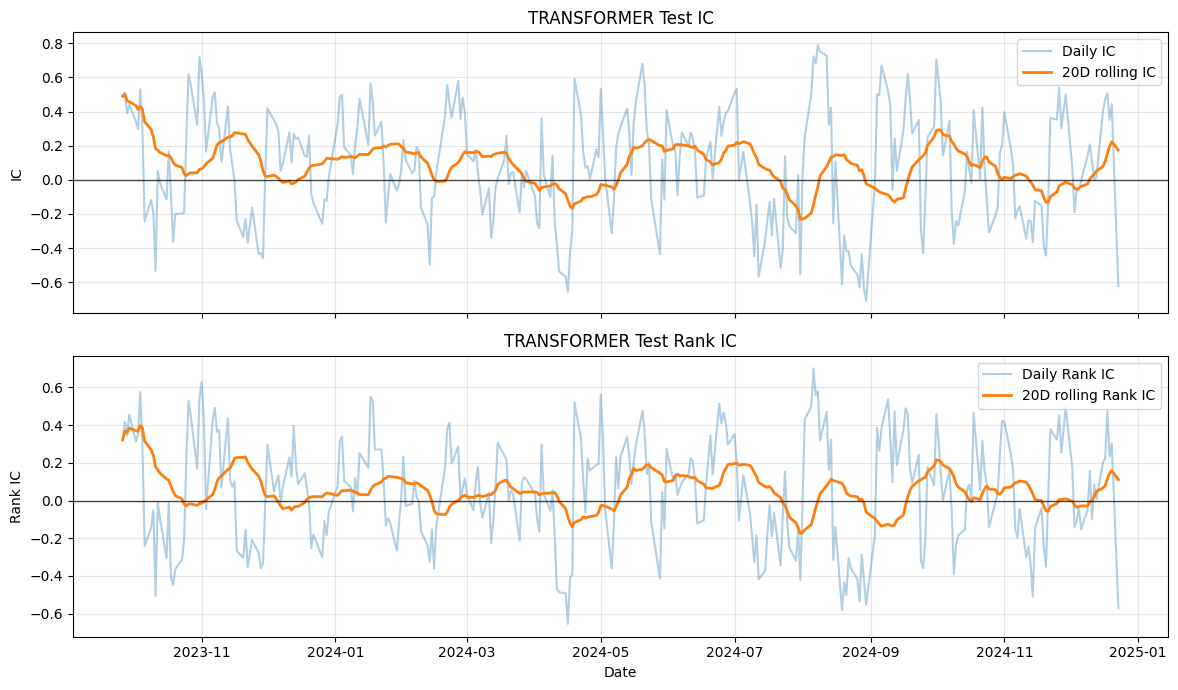

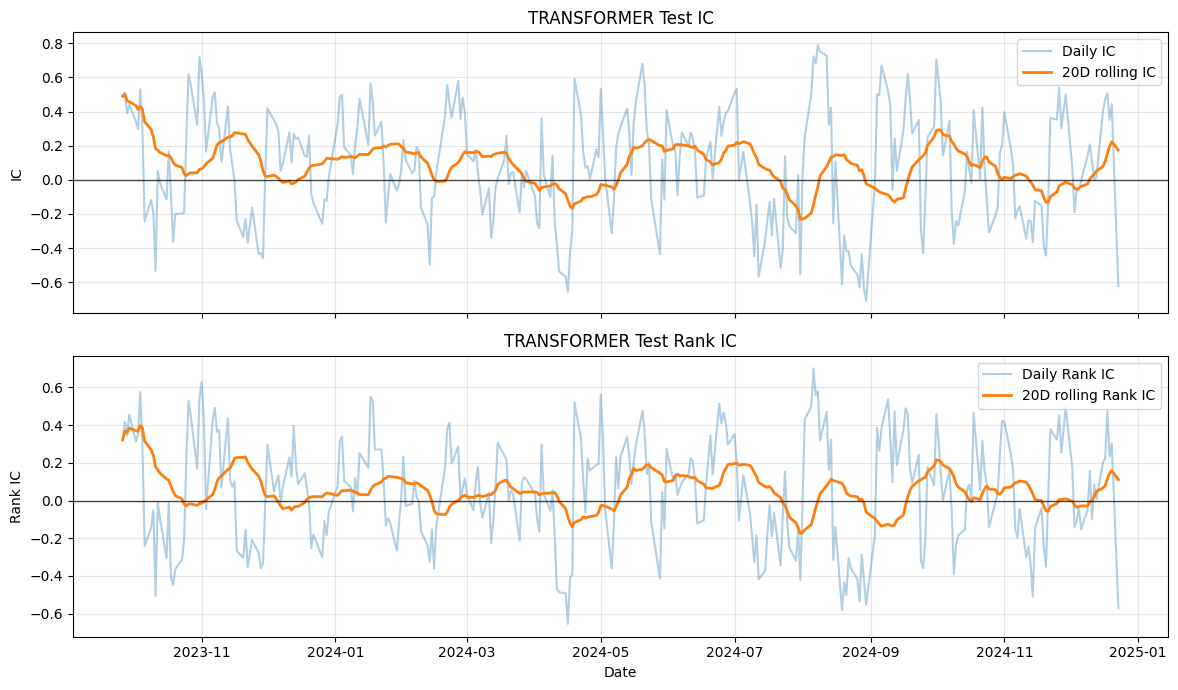

In [7]:
srp.plot_ic_series(results, best_model, split="test", rolling_window=20)


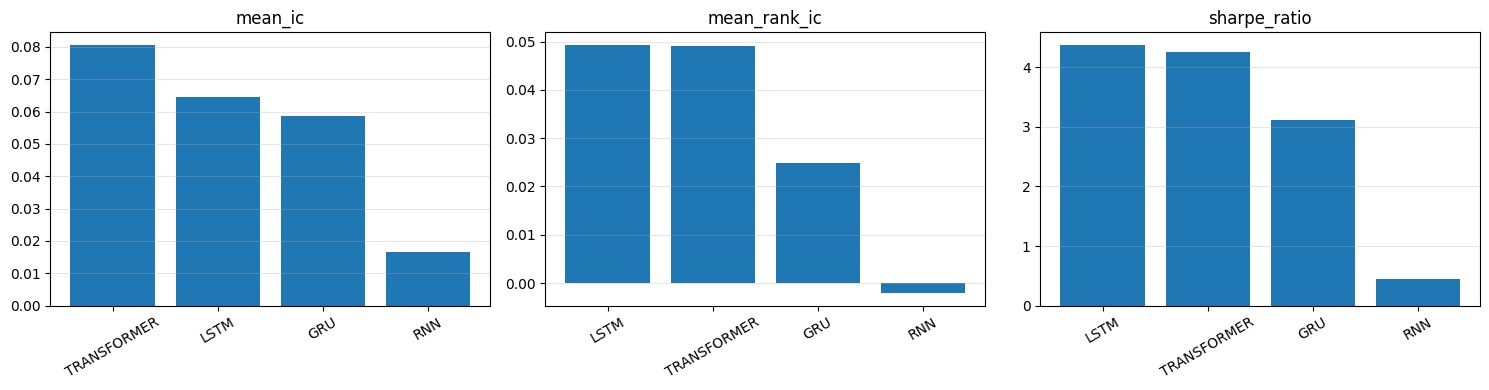

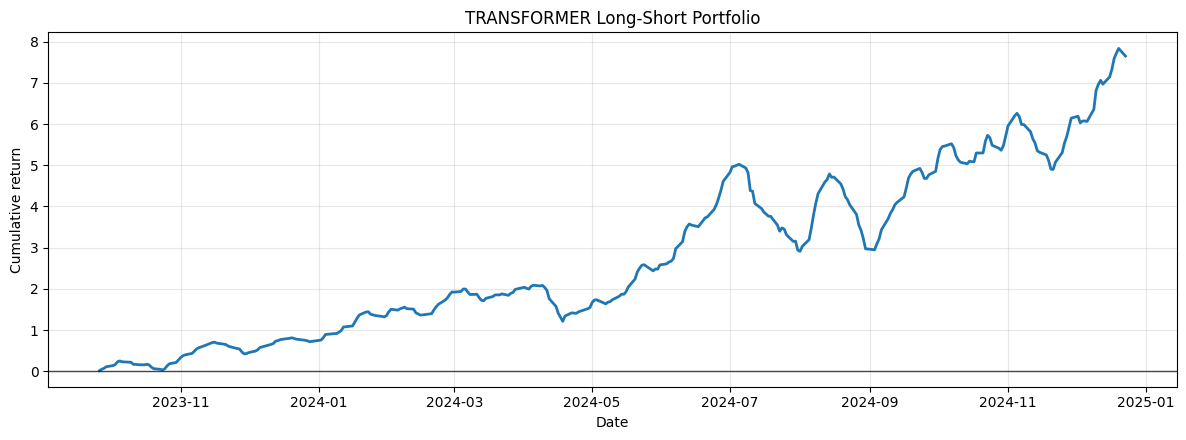

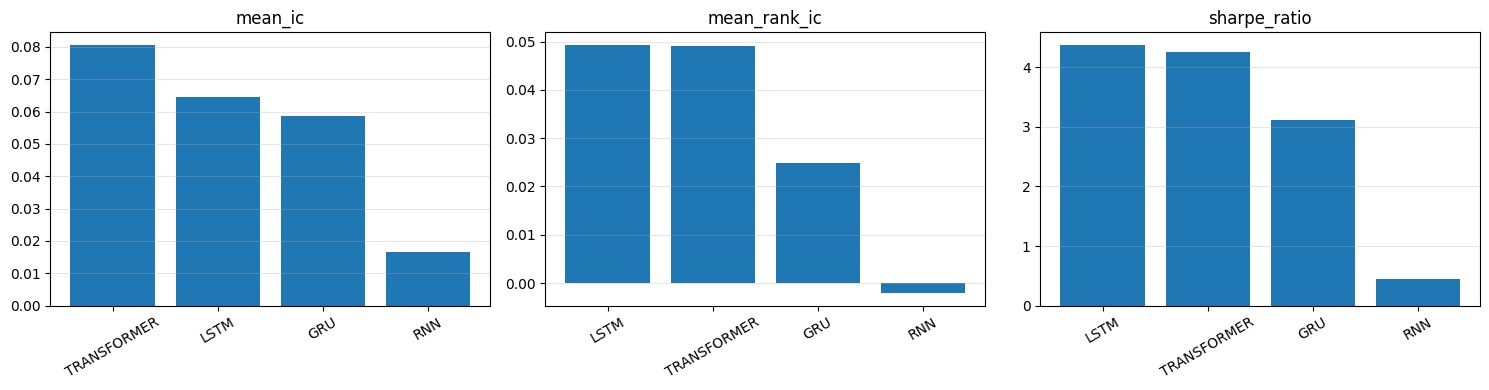

In [16]:
for model_name, result in results.items():
    if "portfolio_curve" not in result:
        portfolio_curve, portfolio_summary = srp.backtest_long_short(result["test_predictions"])
        result["portfolio_curve"] = portfolio_curve
        result["portfolio_summary"] = portfolio_summary
        
srp.plot_portfolio_curve(results, best_model)
srp.plot_summary_bars(summary)


# Prediction diagnostics

Inspect raw predictions, sign accuracy, and the prediction-vs-target scatter plot.


In [13]:
model_name = best_model
pred = results[model_name]["test_predictions"].copy()
pred.head()


,Date,Ticker,prediction,target
0,2023-09-26,AAPL,0.003332,0.002559
1,2023-09-26,ABBV,0.001473,-0.042103
2,2023-09-26,ABT,0.000555,-0.004572
3,2023-09-26,ADBE,0.002929,0.001442
4,2023-09-26,AMD,0.009787,0.042935


In [17]:
pred["pred_sign"] = (pred["prediction"] > 0).astype(int)
pred["true_sign"] = (pred["target"] > 0).astype(int)

sign_accuracy = (pred["pred_sign"] == pred["true_sign"]).mean()
daily_sign_accuracy = pred.groupby("Date").apply(
    lambda x: ((x["prediction"] > 0) == (x["target"] > 0)).mean(),
    include_groups=False,
)

print("Overall sign accuracy:", round(float(sign_accuracy), 4))
daily_sign_accuracy.describe()


Overall sign accuracy: 0.5433


count    314.000000
mean       0.543286
std        0.163859
min        0.183673
25%        0.428571
50%        0.551020
75%        0.673469
max        0.959184
dtype: float64

,Date,Ticker,prediction,target,pred_sign,true_sign
15372,2024-12-23,NVDA,0.009923,-0.038519,1,0
15341,2024-12-23,AMD,0.008548,-0.030578,1,0
15340,2024-12-23,ADBE,0.005904,-0.004611,1,0
15370,2024-12-23,NFLX,0.005356,-0.022086,1,0
15367,2024-12-23,META,0.004916,-0.023906,1,0
15343,2024-12-23,AMZN,0.004373,-0.025193,1,0
15373,2024-12-23,ORCL,0.004311,-0.014781,1,0
15371,2024-12-23,NOW,0.003971,-0.025858,1,0
15347,2024-12-23,CAT,0.003933,-0.007198,1,0
15364,2024-12-23,LLY,0.003787,-0.030492,1,0


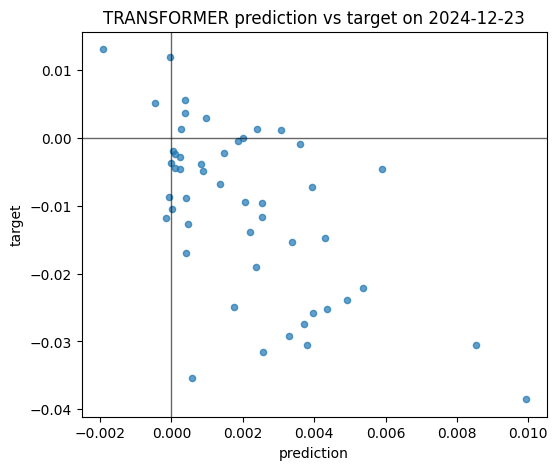

In [18]:
import matplotlib.pyplot as plt

latest_day = pred["Date"].max()
latest_slice = pred[pred["Date"] == latest_day].copy()
display(latest_slice.sort_values("prediction", ascending=False).head(10))

ax = latest_slice.plot.scatter(
    x="prediction",
    y="target",
    figsize=(6, 5),
    alpha=0.7,
    title=f"{model_name} prediction vs target on {latest_day.date()}"
)
ax.axhline(0.0, color="black", linewidth=1, alpha=0.6)
ax.axvline(0.0, color="black", linewidth=1, alpha=0.6)
plt.show()
